# Lecture 12 — Backtesting and Tactical Portfolio Construction
## Validating momentum strategies: walk-forward, CPCV, and the reality check

This companion notebook uses the GAA framework to illustrate, on real data:

1. Two momentum rules as portfolio construction — **time-series** (single asset) and
   **cross-sectional long-only** (rank-weighted) — from `signals.stcma.momentum`.
2. **Walk-forward analysis** — one honest out-of-sample path.
3. **Combinatorial purged cross-validation (CPCV)** — a *distribution* of OOS paths.
4. **Significance**: probabilistic / deflated Sharpe ratio and the
   stationary-bootstrap **reality check / SPA**.
5. A cross-section comparison across macro assets, US industries, and equity styles.

Data: monthly indexed performance from `perf_M.parquet`.
Reusable validation code lives in `signals/ml_pipeline/` and the drivers in
`taa/examples/validation_single_asset.py` and `validation_cross_sectional.py`.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from signals.stcma import (
    TimeSeriesMomentum,
    CrossSectionalMomentum,
    time_series_momentum_returns,
    cross_sectional_momentum_weights,
)
from signals.ml_pipeline import (
    walk_forward_strategy_returns,
    run_cpcv,
    whites_reality_check,
    hansens_spa,
)
from analytics.timeseries_analyzer import (
    probabilistic_sharpe_ratio_from_returns,
    deflated_sharpe_ratio_from_returns,
)
from taa.examples._validation_data import (
    load_single_returns,
    load_returns,
    sharpe,
    MACRO_ASSETS,
    US_INDUSTRIES,
    EQUITY_STYLES,
)

PPY = 12.0  # monthly data
LOOKBACKS_TS = [3, 6, 9, 12, 18, 24]
LOOKBACKS_XS = [3, 6, 9, 12]
QUANTILES = [0.2, 0.3]
pd.set_option("display.float_format", "{:.4f}".format)

## 1. Two momentum rules

**Time-series momentum** (single asset): the position is the *sign of the trailing
$L$-period return*, held over the next period —
$$ w_t = \operatorname{sign}\!\Big(\sum_{i=0}^{L-1} R_{t-i}\Big)\in\{-1,0,+1\},
   \qquad R^{\text{strat}}_{t+1}=w_t R_{t+1}. $$

The signal at $t$ uses only data through $t$ and applies to the *next* return, so it
is causal — perturbing a future return cannot change a past strategy return.

In [2]:
eq = load_single_returns("EQ_US", frequency="M")
print(f"EQ_US monthly returns: {eq.index[0].date()} -> {eq.index[-1].date()} ({len(eq)} obs)")

# No-look-ahead check: bump a future return and confirm nothing earlier changes.
base = time_series_momentum_returns(eq, 12)
bumped = eq.copy(); bumped.iloc[200] += 0.5
after = time_series_momentum_returns(bumped, 12)
changed = (base != after) & ~(base.isna() & after.isna())
print("first changed observation:", int(np.argmax(changed.values)), "(== 200, none earlier)")
assert not changed.iloc[:200].any()

EQ_US monthly returns: 1970-01-31 -> 2025-12-31 (672 obs)
first changed observation: 200 (== 200, none earlier)


**Cross-sectional momentum** (long-only): rank assets by trailing $L$-period return,
hold the top quantile fully invested, with weights that **scale linearly with rank**
(best name gets the largest share):
$$ w_{i,t}\propto\operatorname{rank}_t(i)\ \text{ for the top quantile},
   \qquad w_{i,t}\ge 0,\ \sum_i w_{i,t}=1. $$

In [3]:
macro = load_returns(MACRO_ASSETS, frequency="M", balanced=True)
W = cross_sectional_momentum_weights(macro, lookback=12, quantile=0.3, long_only=True)
latest = W.dropna().iloc[-1]
print("Most recent long-only momentum weights (top-quantile, rank-scaled):")
print(latest[latest > 0].sort_values(ascending=False).round(3))
print(f"sum = {latest.sum():.3f}   (fully invested, no shorts)")

Most recent long-only momentum weights (top-quantile, rank-scaled):
CO_GO   0.5000
EQ_EM   0.3330
EQ_EA   0.1670
Name: 2025-12-31 00:00:00, dtype: float64
sum = 1.000   (fully invested, no shorts)


## 2. Walk-forward analysis — one honest path

Refit the lookback on an expanding training window, collect returns on the next
disjoint block, and roll forward. Concatenating the blocks gives a single
out-of-sample equity path.

51 windows; lookbacks chosen: [3, 9, 12]
OOS annualised Sharpe (rf=0) = +0.45
OOS PSR(>0)                  = 0.999


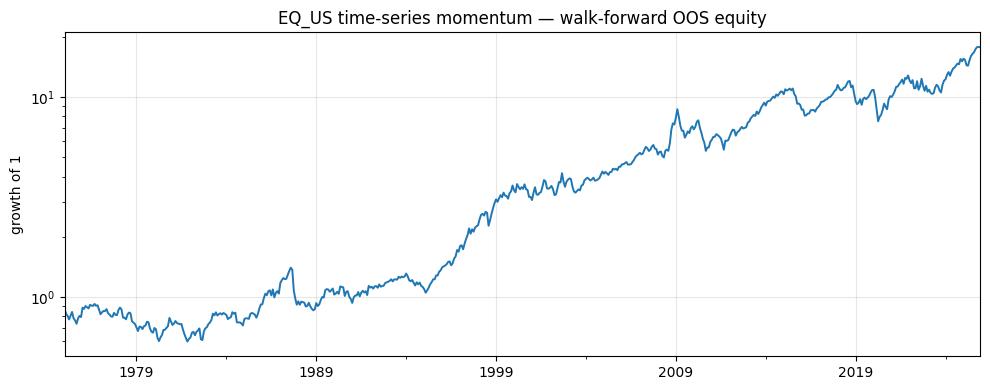

In [4]:
wfa = walk_forward_strategy_returns(
    TimeSeriesMomentum(LOOKBACKS_TS), eq,
    mode="expanding", min_train_size=60, retrain_every=12, test_horizon=12,
)
wfa_sharpe = sharpe(wfa.oos_returns)
print(f"{len(wfa.windows)} windows; lookbacks chosen: "
      f"{sorted(wfa.selected_params.iloc[:, 0].unique().tolist())}")
print(f"OOS annualised Sharpe (rf=0) = {wfa_sharpe:+.2f}")
print(f"OOS PSR(>0)                  = {probabilistic_sharpe_ratio_from_returns(wfa.oos_returns):.3f}")

ax = (1 + wfa.oos_returns.fillna(0)).cumprod().plot(figsize=(10, 4), linewidth=1.4)
ax.set_title("EQ_US time-series momentum — walk-forward OOS equity"); ax.set_yscale("log")
ax.set_ylabel("growth of 1"); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 3. Combinatorial purged CV — a distribution of paths

Split the timeline into $N$ groups, test every combination of $k$, purge and embargo
the training set, and recombine the predictions into $\varphi=\binom{N-1}{k-1}$
full-length OOS paths. The Sharpe of each path is one observation.

N=6, k=2 -> 15 splits, 5 paths
path Sharpe: mean=+0.41  std=0.04  min=+0.37  max=+0.45


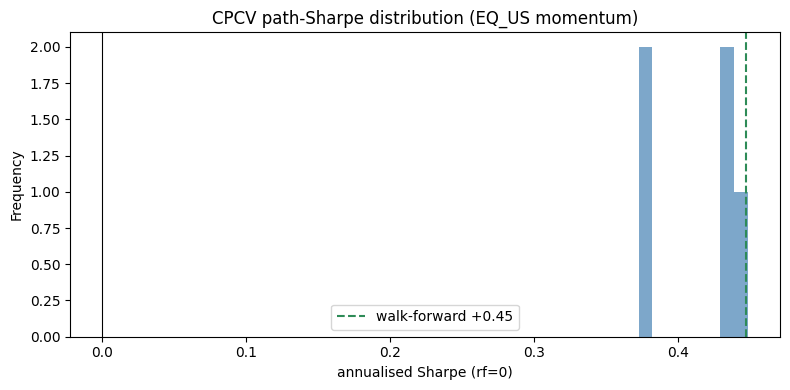

In [5]:
cpcv = run_cpcv(
    TimeSeriesMomentum(LOOKBACKS_TS), eq,
    n_groups=6, n_test_groups=2, embargo_pct=0.02,
    label_horizon=max(LOOKBACKS_TS), periods_per_year=PPY,
)
print(f"N=6, k=2 -> {cpcv.n_splits} splits, {cpcv.n_paths} paths")
print(f"path Sharpe: mean={cpcv.path_sharpes.mean():+.2f}  std={cpcv.path_sharpes.std():.2f}  "
      f"min={cpcv.path_sharpes.min():+.2f}  max={cpcv.path_sharpes.max():+.2f}")

ax = cpcv.path_sharpes.plot(kind="hist", bins=8, alpha=0.7, figsize=(8, 4), color="steelblue")
ax.axvline(wfa_sharpe, color="seagreen", ls="--", label=f"walk-forward {wfa_sharpe:+.2f}")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("CPCV path-Sharpe distribution (EQ_US momentum)")
ax.set_xlabel("annualised Sharpe (rf=0)"); ax.legend(); plt.tight_layout(); plt.show()

## 4. Was the best trial luck?

- **Probabilistic Sharpe ratio (PSR)** — probability the true Sharpe beats a benchmark,
  with the Mertens correction for skew and kurtosis.
- **Deflated Sharpe ratio (DSR)** — PSR against the *expected maximum* Sharpe under the
  null, i.e. deflated for the number of trials.
- **Reality check / SPA** — bootstrap $p$-value that the best of the lookback grid beats
  a zero return, with serial dependence preserved by the stationary bootstrap.

In [6]:
ts = TimeSeriesMomentum(LOOKBACKS_TS)
trials = pd.DataFrame(
    {f"lb{p['lookback']}": ts.strategy_returns(eq, **p) for p in ts.param_grid()}
).dropna(how="any")

rc = whites_reality_check(trials, n_resamples=2000, seed=7)
spa = hansens_spa(trials, n_resamples=2000, seed=7)
dsr = deflated_sharpe_ratio_from_returns(trials)
print(f"White reality check p-value = {rc.p_value:.3f}  (best trial: {rc.best_trial})")
print(f"Hansen SPA p-value          = {spa.p_value_consistent:.3f} "
      f"[{spa.p_value_lower:.3f}, {spa.p_value_upper:.3f}]")
print(f"Deflated Sharpe ratio       = {dsr:.3f}  (N={trials.shape[1]} trials)")
print("\nIn-sample optimism vs out-of-sample evidence:")
print(pd.Series({
    "in-sample best (full)": sharpe(trials[rc.best_trial]),
    "walk-forward OOS": wfa_sharpe,
    "CPCV path mean": cpcv.path_sharpes.mean(),
}).round(2))

White reality check p-value = 0.001  (best trial: lb12)
Hansen SPA p-value          = 0.000 [0.000, 0.000]
Deflated Sharpe ratio       = 0.998  (N=6 trials)

In-sample optimism vs out-of-sample evidence:
in-sample best (full)   0.5300
walk-forward OOS        0.4500
CPCV path mean          0.4100
dtype: float64


## 5. Cross-section: long-only momentum vs. equal weight

The same toolkit applied to three cross-sections. Long-only momentum is tested for
**outperformance over equal weight** (does the rank tilt beat naive diversification
after the search?). A high *absolute* Sharpe is not the same as beating the benchmark.

In [7]:
universes = {"Macro (10)": MACRO_ASSETS, "US industries (10)": US_INDUSTRIES,
             "Equity styles (9)": EQUITY_STYLES}
rows = {}
for name, assets in universes.items():
    R = load_returns(assets, frequency="M", balanced=True)
    ew = R.mean(axis=1)
    in_sample = CrossSectionalMomentum(LOOKBACKS_XS, QUANTILES, long_only=True).fit(R, R.index)
    is_sr = sharpe(in_sample.strategy_returns(R, **in_sample.selected_params_))
    wf = walk_forward_strategy_returns(
        CrossSectionalMomentum(LOOKBACKS_XS, QUANTILES, long_only=True), R,
        mode="expanding", min_train_size=48, retrain_every=12, test_horizon=12)
    cp = run_cpcv(CrossSectionalMomentum(LOOKBACKS_XS, QUANTILES, long_only=True), R,
                  n_groups=6, n_test_groups=2, embargo_pct=0.02,
                  label_horizon=max(LOOKBACKS_XS), periods_per_year=PPY)
    xs = CrossSectionalMomentum(LOOKBACKS_XS, QUANTILES, long_only=True)
    tr = pd.DataFrame({f"lb{p['lookback']}_q{p['quantile']}": xs.strategy_returns(R, **p)
                       for p in xs.param_grid()}).dropna(how="any")
    rc_u = whites_reality_check(tr, benchmark=ew, n_resamples=2000, seed=7)
    rows[name] = {"in-sample SR": is_sr, "WFA OOS SR": sharpe(wf.oos_returns),
                  "CPCV mean SR": cp.path_sharpes.mean(), "RC p vs EW": rc_u.p_value}

summary = pd.DataFrame(rows).T
summary

,in-sample SR,WFA OOS SR,CPCV mean SR,RC p vs EW
Macro (10),0.9649,0.8267,0.8215,0.0085
US industries (10),0.7974,0.6232,0.7477,0.2229
Equity styles (9),1.0720,1.0302,1.0027,0.2454


**Reading the result.** All three universes show a healthy absolute Sharpe — long-only
momentum inherits the market premium — but only the macro cross-section *beats equal
weight* once the search is accounted for. The equity-style result also reflects a short,
recent sample; the validation honestly reports low confidence rather than a flattering
number.

### Takeaways
- Momentum rules are simple and parameterised, hence easy to over-fit.
- Walk-forward gives one honest path; CPCV gives the distribution around it.
- PSR/DSR and the bootstrap reality check turn *"looks good"* into a $p$-value.
- Treat the in-sample Sharpe as the optimistic upper bound, never the answer.